In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Multiply and Accumulate

### Setup

In [2]:
from IPython.display import display_svg
from typing import List, Tuple
from pathlib import Path
import random
import torch
import numpy as np
import pandas as pd
from itertools import combinations_with_replacement
from typing import Callable, Any
import pyrtl
from pyrtl.rtllib.libutils import twos_comp_repr, rev_twos_comp_repr
from pyrtl.rtllib.multipliers import generalized_fma
from pyrtl import (
    WireVector, 
    Const, 
    Input,
    Output, 
    Register, 
    conditional_assignment,
    otherwise,
    concat,
    Simulation, 
    SimulationTrace, 
    reset_working_block
)
from kai.src.utils import custom_render_trace, basic_circuit_analysis
from kai.src.bfloat16 import BF16

In [3]:
output_dir = Path('kai/output')
output_dir

PosixPath('kai/output')

In [4]:
E_BITS  = 8
M_BITS  = 7
MSB     = E_BITS + M_BITS

In [5]:
pyrtl.set_debug_mode(False)

### PyRTL Simple Pipeline

In [6]:
class SimplePipeline(object):
    """ Pipeline builder with auto generation of pipeline registers. """

    def __init__(self):
        self._pipeline_register_map = {}
        self._current_stage_num = 0
        stage_list = [method for method in dir(self) if method.startswith('stage')]
        for stage in sorted(stage_list):
            stage_method = getattr(self, stage)
            stage_method()
            self._current_stage_num += 1

    def __getattr__(self, name):
        try:
            return self._pipeline_register_map[self._current_stage_num][name]
        except KeyError:
            raise pyrtl.PyrtlError(
                'error, no pipeline register "%s" defined for stage %d'
                % (name, self._current_stage_num))

    def __setattr__(self, name, value):
        if name.startswith('_'):
            # do not do anything tricky with variables starting with '_'
            object.__setattr__(self, name, value)
        else:
            next_stage = self._current_stage_num + 1
            pipereg_id = str(self._current_stage_num) + 'to' + str(next_stage)
            rname = 'pipereg_' + pipereg_id + '_' + name
            new_pipereg = pyrtl.Register(bitwidth=len(value), name=rname)
            if next_stage not in self._pipeline_register_map:
                self._pipeline_register_map[next_stage] = {}
            self._pipeline_register_map[next_stage][name] = new_pipereg
            new_pipereg.next <<= value

## Some Basic MAC Examples

### Fully combinatorial

Testing pipelined MAC:


<IPython.core.display.Javascript object>

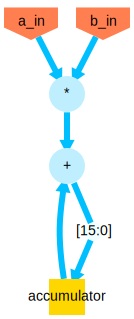

In [7]:
def combinatorial_mac() -> None:
    a      = Input(8, 'a_in')
    b      = Input(8, 'b_in')
    accum  = Register(16, 'accumulator')
    
    accum.next <<= a * b + accum

def test_combinatorial_mac():
    reset_working_block()
    combinatorial_mac()
    sim_trace = pyrtl.SimulationTrace()
    sim = pyrtl.Simulation(tracer=sim_trace)
    
    # Test vectors
    inputs = {
        'a_in':    [1, 0, 1, 0, 1, 0, 0, 0],
        'b_in':    [1, 0, 1, 0, 1, 0, 0, 0]
    }
    trace_list=[
        'a_in', 
        'b_in', 
        'accumulator'
    ]
    
    sim.step_multiple(inputs)
    custom_render_trace(sim_trace, trace_list=trace_list, repr_func=lambda x: int(x))

print("Testing pipelined MAC:")
test_combinatorial_mac()

svg = pyrtl.block_to_svg(split_state=False)
display_svg(svg, raw=True)

### Using SimplePipeline

Testing pipelined MAC:


<IPython.core.display.Javascript object>

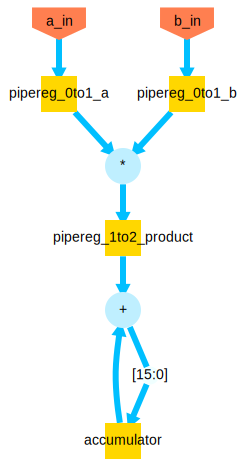

In [8]:
pyrtl.reset_working_block()

class SimpleMAC(SimplePipeline):
    def __init__(self):
        # Create accumulator register outside pipeline stages
        self._accumulator = pyrtl.Register(16, 'accumulator')
        super(SimpleMAC, self).__init__()
        
    def stage0(self):
        # Input stage - receive operands
        self.a = pyrtl.Input(8, 'a_in')
        self.b = pyrtl.Input(8, 'b_in')
        
    def stage1(self):
        # Multiply stage
        self.product = self.a * self.b
        
    def stage2(self):
        # Add stage with accumulation
        self._accumulator.next <<= self.product + self._accumulator

def test_pipeline_mac():
    SimpleMAC()
    sim_trace = pyrtl.SimulationTrace()
    sim = pyrtl.Simulation(tracer=sim_trace)
    
    # Test vectors
    inputs = {
        'a_in':    [1, 0, 1, 0, 1, 0, 0, 0],
        'b_in':    [1, 0, 1, 0, 1, 0, 0, 0]
    }
    trace_list=[
        'a_in', 
        'b_in', 
        'accumulator'
    ]
    
    sim.step_multiple(inputs)
    custom_render_trace(sim_trace, trace_list=trace_list, repr_func=lambda x: int(x))

print("Testing pipelined MAC:")
test_pipeline_mac()

svg = pyrtl.block_to_svg(split_state=False)
display_svg(svg, raw=True)

### Hand built pipelined MAC with reset logic

Testing 8-bit MAC:


<IPython.core.display.Javascript object>

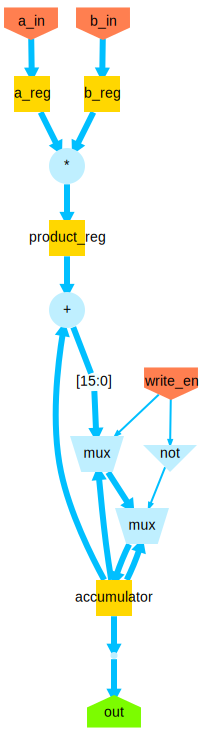

In [9]:
def mac_8bit(
    a_in: WireVector,
    b_in: WireVector,
    clear: WireVector,
    write_en: WireVector
) -> WireVector:
    """
    8-bit pipelined multiply-accumulate unit
    
    Args:
        a_in: 8-bit multiplicand input
        b_in: 8-bit multiplier input
        clear: 1-bit clear signal to reset accumulator
        write_en: 1-bit write enable for accumulation
        
    Returns:
        out: 16-bit output (max value from accumulating 8x8 products)
    """
    assert len(a_in) == len(b_in) == 8
    assert len(clear) == len(write_en) == 1
    
    # Create pipeline registers for input -> multiply stage
    a_reg = Register(8, 'a_reg')
    b_reg = Register(8, 'b_reg')
    # we_reg = Register(1, 'we_reg')  # Pipeline write enable signal
    
    # Register inputs
    a_reg.next <<= a_in
    b_reg.next <<= b_in
    # we_reg.next <<= write_en
    
    # Multiply stage (8x8=16 bits)
    # product = WireVector(16, 'product')
    # product <<= a_reg * b_reg
    
    # Register product and write enable for multiply -> accumulate stage
    product_reg = Register(16, 'product_reg')
    # we_reg2 = Register(1, 'we_reg2')
    product_reg.next <<= a_reg * b_reg
    # we_reg2.next <<= we_reg
    
    # Accumulator register (16 bits)
    accumulator = Register(16, 'accumulator')
    
    # Accumulate or clear
    with conditional_assignment:
        # with clear:
        #     accumulator.next |= 0
        with write_en:  # Only accumulate when write enable is high
            accumulator.next |= product_reg + accumulator
        with otherwise:
            accumulator.next |= accumulator
            
    return accumulator

def test_mac_8bit():
    reset_working_block()
    
    # Create inputs
    a = Input(8, 'a_in')
    b = Input(8, 'b_in')
    clear = Input(1, 'clear')
    write_en = Input(1, 'write_en')
    
    # Create output
    out = Output(16, 'out')
    
    # Instantiate MAC
    out <<= mac_8bit(a, b, clear, write_en)
    
    # Simulate
    sim_trace = SimulationTrace()
    sim = Simulation(tracer=sim_trace)
    
    # Test vectors:
    # 1. Clear accumulator
    # 2. Accumulate 2*3
    # 3. Accumulate 4*5 (write enabled)
    # 4. Skip accumulation (write disabled)
    # 5. Accumulate 3*3 (write enabled)
    inputs = {
        'a_in':     [0,   2,   4,   5,   3,   0],
        'b_in':     [0,   3,   5,   5,   3,   0],
        'clear':    [1,   0,   0,   0,   0,   0],
        'write_en': [0,   1,   1,   0,   1,   0]
    }
    
    sim.step_multiple(inputs)
    
    # Custom representation for values
    def repr_dec(x): return f"{x:3d}"  # Decimal representation
    def repr_hex(x): return f"0x{x:04x}"  # Hex representation
    
    input_repr_map = {
        'a_in': repr_dec,
        'b_in': repr_dec,
        'clear': repr_dec,
        'write_en': repr_dec,
        'product_reg': repr_hex,
        'accumulator': repr_hex,
        'out': repr_hex
    }
    
    trace_list = list(input_repr_map.keys())
    custom_render_trace(sim_trace, trace_list=trace_list, repr_per_name=input_repr_map)

print("Testing 8-bit MAC:")
test_mac_8bit()

svg = pyrtl.block_to_svg(split_state=False)
display_svg(svg, raw=True)


# with open(output_dir / 'pipeline-mac-sync.v', 'w+') as f:
#     pyrtl.output_to_verilog(f, initialize_registers=True)

# Systolic Array

### Processing Element

In [ ]:
def fmac(
    a_in: WireVector,
    b_in: WireVector,
    # clear: WireVector,
    left_en: WireVector,
    up_en: WireVector
) -> WireVector:
    assert len(a_in) == len(b_in) == 8
    assert len(left_en) == len(up_en) == 1 # == len(clear)
    
    # Create pipeline registers for input -> multiply stage
    a_reg = Register(8, 'a_reg')
    b_reg = Register(8, 'b_reg')
    we_reg = Register(1, 'we_reg')  # Pipeline write enable signal
    
    # Register inputs
    a_reg.next <<= a_in
    b_reg.next <<= b_in
    
    # Accumulator register (16 bits)
    accumulator = Register(16, 'accumulator')
    # accumulator.next <<= generalized_fma([(a_reg, b_reg)], accumulator)
    
    # Accumulate or clear
    with conditional_assignment:
        with we_reg:  # Only accumulate when write enable is high
            accumulator.next |= generalized_fma([(a_reg, b_reg)], [accumulator])
        with otherwise:
            accumulator.next |= accumulator
            we_reg.next |= left_en & up_en
            
    return a_reg, b_reg, we_reg, accumulator

def basic_systolic_array(
    matsize: int, 
    left_inputs: List[WireVector], 
    top_inputs: List[WireVector], 
    clear: WireVector, 
    write_en: WireVector
) -> List[WireVector]:
    # Left inputs is a list of inputs to the left side of the systolic array, each wire 8 bits wide

    pe_array = []
    for i in range(matsize): # Iterate over rows
        pe_array.append([])
        for j in range(matsize): # Iterate over columns
            pe_array[i].append(fmac(left_inputs[i], top_inputs[j], clear, write_en))

def MMArray(data_width, matrix_size, data_in, new_weights, weights_in, weights_we):
    '''
    data_in: 256-array of 8-bit activation values from systolic_setup buffer
    new_weights: 256-array of 1-bit control values indicating that new weight should be used
    weights_in: output of weight FIFO (8 x matsize x matsize bit wire)
    weights_we: 1-bit signal to begin writing new weights into the matrix
    '''

    # For signals going to the right, store in a var; for signals going down, keep a list
    # For signals going down, keep a copy of inputs to top row to connect to later
    weights_in_top = [ WireVector(data_width) for i in range(matrix_size) ]  # input weights to top row
    weights_in_last = [x for x in weights_in_top]

    weights_enable_top = [ WireVector(1) for i in range(matrix_size) ]  # weight we to top row
    weights_enable = [x for x in weights_enable_top]

    data_in_left = [ WireVector(data_width) for i in range(matrix_size) ]  # data input to left column (arr[i][0])
    data_in_last = [x for x in data_in_left]

    data_out = [Const(0) for i in range(matrix_size)]  # will hold output from final row

    # Build array of MACs
    for i in range(matrix_size):  # for each row
        din = data_in[i]
        switchin = new_weights[i]
        #probe(switchin, "switch" + str(i))
        for j in range(matrix_size):  # for each column
            left_out, top_out, we_out, accum_out = fmac(data_width, matrix_size, din, data_out[j], switchin, weights_in_last[j], weights_enable[j], weights_tag[j])

            fmac(data_in_last[j], weights_in_last[j], )

            #probe(data_out[j], "MACacc{}_{}".format(i, j))
            #probe(acc_out, "MACout{}_{}".format(i, j))
            #probe(din, "MACdata{}_{}".format(i, j))
            weights_in_last[j] = newweight
            weights_enable[j] = newwe
            weights_tag[j] = newtag
            data_out[j] = acc_out


def test_fmac():
    reset_working_block()
    
    # Create inputs
    a = Input(8, 'a_in')
    b = Input(8, 'b_in')
    clear = Input(1, 'clear')
    write_en = Input(1, 'write_en')
    
    # Create output
    out = Output(16, 'out')
    
    # Instantiate MAC
    out <<= fmac(a, b, clear, write_en)
    
    # Simulate
    sim_trace = SimulationTrace()
    sim = Simulation(tracer=sim_trace)
    
    # Test vectors:
    # 1. Clear accumulator
    # 2. Accumulate 2*3
    # 3. Accumulate 4*5 (write enabled)
    # 4. Skip accumulation (write disabled)
    # 5. Accumulate 3*3 (write enabled)
    inputs = {
        'a_in':     [0,   2,   4,   5,   3,   0],
        'b_in':     [0,   3,   5,   5,   3,   0],
        'clear':    [1,   0,   0,   0,   0,   0],
        'write_en': [0,   1,   1,   0,   1,   0]
    }
    
    sim.step_multiple(inputs)
    
    # Custom representation for values
    def repr_dec(x): return f"{x:3d}"  # Decimal representation
    def repr_hex(x): return f"0x{x:04x}"  # Hex representation
    
    input_repr_map = {
        'a_in': repr_dec,
        'b_in': repr_dec,
        'clear': repr_dec,
        'write_en': repr_dec,
        'accumulator': repr_dec,
        'out': repr_dec
    }
    
    trace_list = list(input_repr_map.keys())
    custom_render_trace(sim_trace, trace_list=trace_list, repr_per_name=input_repr_map)

print("Testing FMA based accumulator:")
test_fmac()

svg = pyrtl.block_to_svg(split_state=False)
display_svg(svg, raw=True)

Testing FMA based accumulator:


PyrtlError: error, expecting a wirevector, int, or verilog-style const string got (<pyrtl.wire.Register object at 0x13073e930>, <pyrtl.wire.Register object at 0x13073c3b0>, <pyrtl.wire.Register object at 0x13073c470>, <pyrtl.wire.Register object at 0x127edb620>) instead

In [ ]:
def processing_element(
    left_in: WireVector, # left input data
    top_in: WireVector,  # top input data
    enable: WireVector,  # enable signal
    data_width: int,     # size of input data
    i: int,              # row index
    j: int               # column index
):
    assert len(enable) == 1
    assert len(left_in) == len(top_in) == data_width

    left_in_reg  = Register(data_width, f'left_in_reg_{i}_{j}')
    top_in_reg   = Register(data_width, f'top_in_reg_{i}_{j}')
    product      = Register(data_width * 2, f'product_{i}_{j}')
    accumulator  = Register(data_width * 2, f'accumulator_{i}_{j}')

    left_in_reg.next <<= left_in
    top_in_reg.next <<= top_in
    with conditional_assignment:
        with enable:
           product.next <<= left_in_reg * top_in_reg


4294967295

In [59]:
basic_circuit_analysis()

Pre-synthesis Results:
The total block timing delay is  1255.6000000000001
Max frequency of block:  610.2770657878676 MHz
Estimated Area of block 0.00789411744 mm^2 using 130nm process

Post-synthesis Results:
Synthesis Results:
tmp2247_utils_line26_synth_16/1W:
Wire Traceback, most recent call last 
  File "<frozen runpy>", line 198, in _run_module_as_main
   File "<frozen runpy>", line 88, in _run_code
   File "/opt/homebrew/Caskroom/miniconda/base/envs/dsc180/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
   File "/opt/homebrew/Caskroom/miniconda/base/envs/dsc180/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
   File "/opt/homebrew/Caskroom/miniconda/base/envs/dsc180/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
   File "/opt/homebrew/Caskroom/miniconda/base/envs/dsc180/lib/python3.12/site-packages/tornado/platform